# Natural Language Processing

/home/lorin-cairo/.conda/envs/medos/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Embedding file not found — generating embeddings...


Batches: 100%|██████████| 859/859 [02:14<00:00,  6.39it/s]


Embeddings saved for future use.
Epoch [1/80] | Loss: 93.7055
Epoch [2/80] | Loss: 76.4875
Epoch [3/80] | Loss: 73.7431
Epoch [4/80] | Loss: 72.0151
Epoch [5/80] | Loss: 70.6449
Epoch [6/80] | Loss: 69.5512
Epoch [7/80] | Loss: 68.4714
Epoch [8/80] | Loss: 67.4419
Epoch [9/80] | Loss: 66.5879
Epoch [10/80] | Loss: 65.7900
Epoch [11/80] | Loss: 64.6741
Epoch [12/80] | Loss: 63.7804
Epoch [13/80] | Loss: 62.9382
Epoch [14/80] | Loss: 61.8684
Epoch [15/80] | Loss: 61.0591
Epoch [16/80] | Loss: 59.9237
Epoch [17/80] | Loss: 59.0467
Epoch [18/80] | Loss: 58.3168
Epoch [19/80] | Loss: 57.0756
Epoch [20/80] | Loss: 56.2413
Epoch [21/80] | Loss: 55.0090
Epoch [22/80] | Loss: 53.9662
Epoch [23/80] | Loss: 52.9137
Epoch [24/80] | Loss: 51.7564
Epoch [25/80] | Loss: 50.6566
Epoch [26/80] | Loss: 49.5971
Epoch [27/80] | Loss: 48.6371
Epoch [28/80] | Loss: 46.9991
Epoch [29/80] | Loss: 45.7545
Epoch [30/80] | Loss: 44.7613
Epoch [31/80] | Loss: 43.4283
Epoch [32/80] | Loss: 41.9307
Epoch [33/80] | 

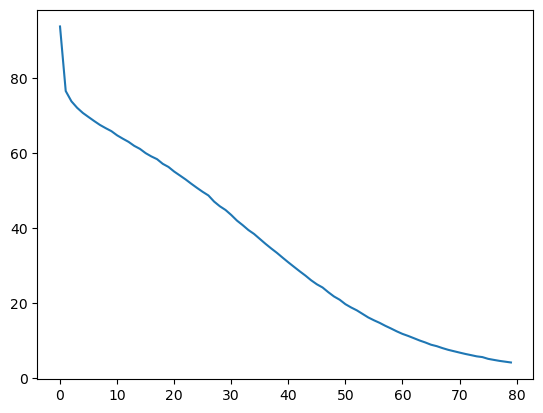

In [ ]:
"""
Sentiment Classification using SentenceTransformers and a Simple PyTorch Model
-------------------------------------------------------------------------------
This script trains a neural network to classify tweet sentiments using 
pre-computed SentenceTransformer embeddings.
"""

import pickle
from collections import Counter

import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from torch.utils.data import Dataset, DataLoader

# =============================================================================
# Configuration
# =============================================================================

DATA_PATH = "data/Tweets.csv"
PICKLE_PATH = "data/tweets_X.pkl"
BATCH_SIZE = 128
NUM_EPOCHS = 80
TEST_SIZE = 0.5
RANDOM_SEED = 123
EMBEDDING_MODEL = "sentence-transformers/all-mpnet-base-v1"

# =============================================================================
# Data Loading & Preprocessing
# =============================================================================

# Load dataset
df = pd.read_csv(DATA_PATH).dropna()

# Map sentiment categories to numeric labels
sentiment_map = {"negative": 0, "neutral": 1, "positive": 2}
df["class"] = df["sentiment"].map(sentiment_map)

# =============================================================================
# Feature Preparation
# =============================================================================

# Load or compute embeddings
try:
    with open(PICKLE_PATH, "rb") as f:
        X = pickle.load(f)
    print("Loaded precomputed embeddings.")
except FileNotFoundError:
    print("Embedding file not found — generating embeddings...")
    emb_model = SentenceTransformer(EMBEDDING_MODEL)
    X = emb_model.encode(df["text"].values, show_progress_bar=True)
    with open(PICKLE_PATH, "wb") as f:
        pickle.dump(X, f)
    print("Embeddings saved for future use.")

y = df["class"].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED
)

# =============================================================================
# PyTorch Dataset & DataLoader
# =============================================================================

class SentimentDataset(Dataset):
    """Custom Dataset for sentiment classification."""

    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_loader = DataLoader(SentimentDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(SentimentDataset(X_test, y_test), batch_size=len(X_test))

# =============================================================================
# Model Definition
# =============================================================================

class SentimentModel(nn.Module):
    """Simple feedforward neural network for sentiment classification."""

    """
    First layer projects the embeddings into a smaller dim latent space
    ReLU activation introduces non-linearity to help capture complex relationships
    Second linear layer maps latent representation to output classification
    Logsoftmax converts raw scores into normalized log-probabilities which can be used for cross entropy loss
    """
    def __init__(self, input_dim, hidden_dim=128, num_classes=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_classes),
            nn.LogSoftmax(dim=1)
        )

    def forward(self, x):
        return self.net(x)

# Initialize model, loss, and optimizer
model = SentimentModel(input_dim=X_train.shape[1])
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters())

# =============================================================================
# Training Loop
# =============================================================================

def train_model(model, train_loader, criterion, optimizer, num_epochs):
    """Train the model and return training losses."""
    losses = []
    model.train()

    for epoch in range(num_epochs):
        epoch_loss = 0.0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            y_pred_log = model(X_batch)
            loss = criterion(y_pred_log, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        losses.append(epoch_loss)
        print(f"Epoch [{epoch+1}/{num_epochs}] | Loss: {epoch_loss:.4f}")

    return losses


train_losses = train_model(model, train_loader, criterion, optimizer, NUM_EPOCHS)

# Plot training loss
sns.lineplot(x=range(len(train_losses)), y=train_losses)

# =============================================================================
# Evaluation
# =============================================================================

def evaluate_model(model, data_loader):
    """Evaluate model accuracy on test data."""
    model.eval()
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            y_pred_log = model(X_batch)
            y_pred = torch.argmax(y_pred_log, dim=1)

    acc = accuracy_score(y_true=y_batch.numpy(), y_pred=y_pred.numpy())
    return acc


accuracy = evaluate_model(model, test_loader)
print(f"\nModel Accuracy: {accuracy * 100:.2f}%")

# Naive baseline: predict the most common class
baseline_acc = Counter(y_test).most_common(1)[0][1] / len(y_test) * 100
print(f"Naive Baseline Accuracy: {baseline_acc:.2f}%")


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device set to use cuda:0


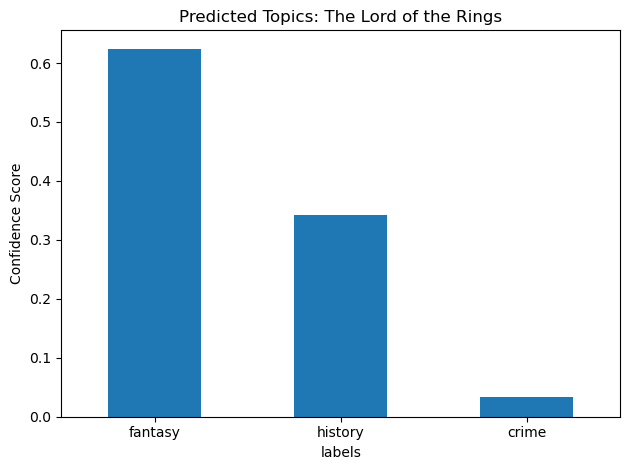


Multi-label classification for first document:
  crime      → 0.157
  fantasy    → 0.036
  history    → 0.022


In [1]:
"""
Zero-Shot Text Classification Demo
-----------------------------------
Classifies text documents into candidate topics using a pretrained
Hugging Face model (`facebook/bart-large-mnli`).
"""

from transformers import pipeline
import pandas as pd
import matplotlib.pyplot as plt

# Model Setup
TASK = "zero-shot-classification"
MODEL_NAME = "facebook/bart-large-mnli"

# Load the pretrained zero-shot classifier
classifier = pipeline(task=TASK, model=MODEL_NAME)


# =============================================================================
# Input Data
# =============================================================================
documents = [
    # Crime novel: Raymond Chandler
    (
        "It was about eleven o’clock in the morning, mid October, with the sun not shining "
        "and a look of hard wet rain in the clearness of the foothills. I was wearing my "
        "powder-blue suit... I was everything the well-dressed private detective ought to be."
    ),
    # Fantasy novel: J.R.R. Tolkien
    (
        "When Mr. Bilbo Baggins of Bag End announced that he would shortly be celebrating "
        "his eleventy-first birthday with a party of special magnificence, there was much "
        "talk and excitement in Hobbiton."
    ),
    # Non-fiction / History: Bill Bryson
    (
        "Welcome. And congratulations. I am delighted that you could make it. Getting here "
        "wasn’t easy, I know... trillions of drifting atoms had somehow to assemble in an "
        "intricate and curiously obliging manner to create you."
    ),
]

candidate_labels = ["crime", "fantasy", "history"]


# =============================================================================
# Model Inference
# =============================================================================
# Perform zero-shot classification for all documents at once
results = classifier(documents, candidate_labels=candidate_labels)

# =============================================================================
# Visualization Example
# =============================================================================
# Convert one example (second document) to DataFrame for plotting
example_idx = 1  # "The Lord of the Rings"
example_result = pd.DataFrame({
    "labels": results[example_idx]["labels"],
    "scores": results[example_idx]["scores"]
})

ax = example_result.plot.bar(
    x="labels",
    y="scores",
    rot=0,
    title="Predicted Topics: The Lord of the Rings",
    legend=False
)
ax.set_ylabel("Confidence Score")
plt.tight_layout()
plt.show()

# =============================================================================
# Multi-Label Classification Example
# =============================================================================
# Allow multiple labels to be true simultaneously (multi-label mode)
multi_label_result = classifier(
    documents[0],
    candidate_labels=candidate_labels,
    multi_label=True
)

print("\nMulti-label classification for first document:")
for label, score in zip(multi_label_result["labels"], multi_label_result["scores"]):
    print(f"  {label:<10} → {score:.3f}")